# `log_20260417_094053.csv` Review

This notebook is reorganised around the four operating phases that mattered in yesterday's run:

1. **P1 / 5%** - cooldown toward `-10 C` in the coldest thermocouples, then recovery toward `15 C` at the flow meter
2. **P2 / 40%** - cooldown to about `-50 C` and warmup back toward `-30 C`
3. **P3 / 60%** - deeper cooldown to roughly `-55 to -60 C` and warmup back toward `-30 C`
4. **P4 / 40%** - warmup from about `-30 C` to `0 C`

The total HFE charge was about `6 kg`, but the actively recirculating liquid inventory was closer to `4 kg` at room temperature, with the remaining volume kept as a top gas trap so the loop can stay filled as the liquid densifies during cooldown. The calculations below therefore report circulated mass in equivalent turnovers of that active liquid inventory.


In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np, pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display
import orca
import orca.notebook
import orca.logbook as orca_logbook

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('load_ext', 'autoreload')
    ip.run_line_magic('autoreload', '2')

importlib.reload(orca.notebook)
importlib.reload(orca_logbook)
orca = importlib.reload(orca)

TOTAL_HFE_CHARGE_KG = 6.0
ACTIVE_HFE_LIQUID_KG = 4.0

LOG_PATH = '/home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260417_094053.csv'


## Thermocouple Calibration

This notebook now uses the shared legacy correction path for pre-fix logs.

The April 10 affine export is still **not** applied directly, because it was produced while the `T`-type loop probes (`TTEST`, `TFO`, `TTI`, `TTO`, `TMI`) were being decoded as `K`-type in firmware. Instead, `orca.prepare_flow_log_review(...)` back-converts the logged wrong-type temperatures to estimated `T`-type temperatures and then room-anchors the loop probes on the warmest stable flow-meter segment before any plots or statistics are generated.

In [2]:
TC_CALIBRATION_ACTIVE = False

def apply_tc_calibration(df):
    """No-op: legacy correction is now applied inside orca.prepare_flow_log_review."""
    return df

print('Legacy wrong-type TC reconstruction is applied inside orca.prepare_flow_log_review for this pre-fix log; the old April 10 affine export remains disabled.')

Legacy wrong-type TC reconstruction is applied inside orca.prepare_flow_log_review for this pre-fix log; the old April 10 affine export remains disabled.


In [3]:
PHASE_TITLES = {
    'P1': '5% command check',
    'P2': '40% cooldown and rebound',
    'P3': '60% deeper cooldown and rebound',
    'P4': '40% final warmup',
}
PHASE_REQUESTS = {
    'P1': '5% pump speed: cooldown to -10 C then warmup to 15 C',
    'P2': '40% pump speed: cooldown to -50 C then warmup to -30 C',
    'P3': '60% pump speed: cooldown to about -55 to -60 C then warmup to -30 C',
    'P4': '40% pump speed: warmup to 0 C',
}
PHASE_COLORS = {
    'P1': '#2563eb',
    'P2': '#f97316',
    'P3': '#14b8a6',
    'P4': '#ef4444',
}
PHASE_ORDER = ('P1', 'P2', 'P3', 'P4')

review = orca.prepare_flow_log_review(LOG_PATH)
apply_tc_calibration(review.data)  # no-op: legacy correction already applied in prepare_flow_log_review
run = orca.segment_slice(review.data, review.segment_summary.loc[review.run_segment_id]).copy().sort_values('time_s')
run_liquid, sweep_windows, _, _ = orca.command_step_summary(run)
run_start_s = float(run_liquid['time_s'].min())

phase_frames = {}
phase_rows = []

for phase_index, (_, window) in enumerate(sweep_windows.iterrows(), start=1):
    phase_key = f'P{phase_index}'
    frame = (
        run_liquid[
            run_liquid['time_s'].between(float(window['start_s']), float(window['end_s']))
        ]
        .copy()
        .sort_values('time_s')
        .reset_index(drop=True)
    )
    frame['phase'] = phase_key
    frame['phase_label'] = PHASE_TITLES[phase_key]
    frame['phase_note'] = PHASE_REQUESTS[phase_key]
    frame['elapsed_phase_s'] = frame['time_s'] - frame['time_s'].iloc[0]
    frame['elapsed_run_s'] = frame['time_s'] - run_start_s
    frame['elapsed_s'] = frame['elapsed_phase_s']
    frame['dt_s'] = frame['time_s'].diff().fillna(0.0).clip(lower=0.0)
    frame['mass_increment_kg'] = frame['mass_flow_kgmin_si'] * frame['dt_s'] / 60.0
    frame['volume_increment_l'] = frame['volume_flow_lmin_si'] * frame['dt_s'] / 60.0
    frame['cum_mass_phase_kg'] = frame['mass_increment_kg'].cumsum()
    frame['cum_volume_phase_l'] = frame['volume_increment_l'].cumsum()
    frame['cum_mass_kg'] = frame['cum_mass_phase_kg']
    frame['cum_volume_l'] = frame['cum_volume_phase_l']
    if review.valid_temp_cols:
        frame['temp_mean_C'] = frame[list(review.valid_temp_cols)].mean(axis=1)
        frame['temp_span_C'] = frame[list(review.valid_temp_cols)].max(axis=1) - frame[list(review.valid_temp_cols)].min(axis=1)
        tc_min_series = frame[list(review.valid_temp_cols)].min(axis=1)
        tc_max_series = frame[list(review.valid_temp_cols)].max(axis=1)
    else:
        frame['temp_mean_C'] = np.nan
        frame['temp_span_C'] = np.nan
        tc_min_series = pd.Series(np.nan, index=frame.index)
        tc_max_series = pd.Series(np.nan, index=frame.index)

    frame['tc_min_C'] = tc_min_series
    frame['tc_max_C'] = tc_max_series
    phase_frames[phase_key] = frame

    phase_rows.append(
        {
            'phase': phase_key,
            'phase_title': PHASE_TITLES[phase_key],
            'requested_window': PHASE_REQUESTS[phase_key],
            'command_pct': float(window['cmd_pct']),
            'start_min_in_log': float(window['start_s'] / 60.0),
            'end_min_in_log': float(window['end_s'] / 60.0),
            'duration_min': float((window['end_s'] - window['start_s']) / 60.0),
            'samples': int(len(frame)),
            'flow_temp_start_C': float(frame['temperature_c_si'].iloc[0]),
            'flow_temp_min_C': float(frame['temperature_c_si'].min()),
            'flow_temp_max_C': float(frame['temperature_c_si'].max()),
            'flow_temp_end_C': float(frame['temperature_c_si'].iloc[-1]),
            'tc_mean_start_C': float(frame['temp_mean_C'].iloc[0]),
            'tc_mean_min_C': float(frame['temp_mean_C'].min()),
            'tc_mean_max_C': float(frame['temp_mean_C'].max()),
            'tc_mean_end_C': float(frame['temp_mean_C'].iloc[-1]),
            'coldest_tc_C': float(frame['tc_min_C'].min()),
            'warmest_tc_C': float(frame['tc_max_C'].max()),
            'mass_transferred_kg': float(frame['mass_increment_kg'].sum()),
            'volume_transferred_l': float(frame['volume_increment_l'].sum()),
            'active_inventory_turnovers_x': float(frame['mass_increment_kg'].sum() / ACTIVE_HFE_LIQUID_KG),
            'median_mass_flow_kgmin': float(frame['mass_flow_kgmin_si'].median()),
            'median_volume_flow_lmin': float(frame['volume_flow_lmin_si'].median()),
            'median_pump_input_power_w': float(frame['pump_input_power_w'].median()),
            'median_freq_hz': float(frame['pump_freq_hz'].median()),
            'median_delta_p_bar': float(frame['delta_p_bar_recomputed'].median()),
        }
    )

phase_summary = pd.DataFrame(phase_rows).set_index('phase').loc[list(PHASE_ORDER)]

analysis_cd = pd.concat([phase_frames[key] for key in PHASE_ORDER], ignore_index=True)
analysis_cd = analysis_cd.sort_values('time_s').reset_index(drop=True)
analysis_cd['elapsed_s'] = analysis_cd['time_s'] - analysis_cd['time_s'].iloc[0]
analysis_cd['elapsed_run_s'] = analysis_cd['elapsed_s']
analysis_cd['cum_mass_kg'] = analysis_cd['mass_increment_kg'].cumsum()
analysis_cd['cum_volume_l'] = analysis_cd['volume_increment_l'].cumsum()


In [4]:
def _shade_segment_summary(ax):
    for _, row in review.segment_summary.iterrows():
        color = orca_logbook.SEGMENT_CLASS_COLORS.get(str(row['classification']), '0.85')
        ax.axvspan(float(row['start_s']) / 60.0, float(row['end_s']) / 60.0, color=color, alpha=0.10)



def _add_phase_windows(ax, *, show_labels=False):
    for phase_key, row in phase_summary.iterrows():
        ax.axvspan(
            float(row['start_min_in_log']),
            float(row['end_min_in_log']),
            color=PHASE_COLORS[phase_key],
            alpha=0.14,
        )
        if show_labels:
            midpoint = 0.5 * (float(row['start_min_in_log']) + float(row['end_min_in_log']))
            ax.text(
                midpoint,
                0.98,
                phase_key,
                transform=ax.get_xaxis_transform(),
                ha='center',
                va='top',
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.22', fc='white', ec=PHASE_COLORS[phase_key], alpha=0.95),
            )



def plot_main_overview_with_phases():
    data = review.data.copy().sort_values('time_s')
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

    ax_cmd = axes[0]
    ax_freq = ax_cmd.twinx()
    ax_cmd.plot(data['t_min'], data['pump_cmd_pct'], color='#111827', label='Pump command / frequency')
    _shade_segment_summary(ax_cmd)
    _add_phase_windows(ax_cmd, show_labels=True)
    ax_cmd.set_ylabel('Pump command [%]')
    ax_cmd.set_ylim(*orca_logbook.MAIN_OVERVIEW_PUMP_CMD_YLIM)
    ax_freq.set_ylabel('Pump frequency [Hz]')
    ax_freq.set_ylim(*orca_logbook.MAIN_OVERVIEW_PUMP_FREQ_YLIM)
    ax_cmd.set_title('Full log overview with the four analysis phases highlighted')
    phase_handles = [
        Patch(facecolor=PHASE_COLORS[key], edgecolor='none', alpha=0.22, label=f"{key}: {phase_summary.loc[key, 'command_pct']:.0f}%")
        for key in PHASE_ORDER
    ]
    line_handles = ax_cmd.get_lines()
    ax_cmd.legend(
        line_handles + phase_handles,
        [handle.get_label() for handle in line_handles] + [handle.get_label() for handle in phase_handles],
        loc='best',
        ncols=3,
    )

    axes[1].plot(data['t_min'], data['temperature_c_si'], label='Flow-meter temperature [°C]')
    for column in review.valid_temp_cols:
        axes[1].plot(data['t_min'], data[column], alpha=0.75, label=orca.tc_display_name(column))
    _shade_segment_summary(axes[1])
    _add_phase_windows(axes[1])
    axes[1].set_ylabel('Temperature [°C]')
    axes[1].set_ylim(*orca_logbook.MAIN_OVERVIEW_TEMPERATURE_YLIM)
    axes[1].legend(loc='best', ncols=max(1, min(4, len(review.valid_temp_cols) + 1)))

    ax_mass = axes[2]
    ax_volume = ax_mass.twinx()
    ax_mass.plot(data['t_min'], data['mass_flow_kgmin_si'], color='#2563eb', label='Mass flow [kg/min]')
    ax_volume.plot(data['t_min'], data['volume_flow_lmin_si'], color='#dc2626', label='Volume flow [L/min]')
    _shade_segment_summary(ax_mass)
    _add_phase_windows(ax_mass)
    ax_mass.set_ylabel('Mass flow [kg/min]')
    ax_mass.set_ylim(*orca_logbook.MAIN_OVERVIEW_MASS_FLOW_YLIM)
    ax_volume.set_ylabel('Volume flow [L/min]')
    ax_volume.set_ylim(*orca_logbook.MAIN_OVERVIEW_VOLUME_FLOW_YLIM)
    flow_handles = ax_mass.get_lines() + ax_volume.get_lines()
    ax_mass.legend(flow_handles, [handle.get_label() for handle in flow_handles], loc='best')

    axes[3].plot(data['t_min'], data['pump_pressure_before_bar_abs'], label='Before pump [bar abs]')
    axes[3].plot(data['t_min'], data['pump_pressure_after_bar_abs'], label='After pump [bar abs]')
    axes[3].plot(data['t_min'], data['pump_pressure_tank_bar_abs'], label='Tank [bar abs]')
    _shade_segment_summary(axes[3])
    _add_phase_windows(axes[3])
    axes[3].set_ylabel('Pressure [bar abs]')
    axes[3].set_ylim(*orca_logbook.MAIN_OVERVIEW_PRESSURE_YLIM)
    axes[3].set_xlabel('Elapsed time [min]')
    axes[3].legend(loc='best')
    return fig


## Main Plot

The first figure keeps the full run in view and highlights the four analysis windows directly on the log.


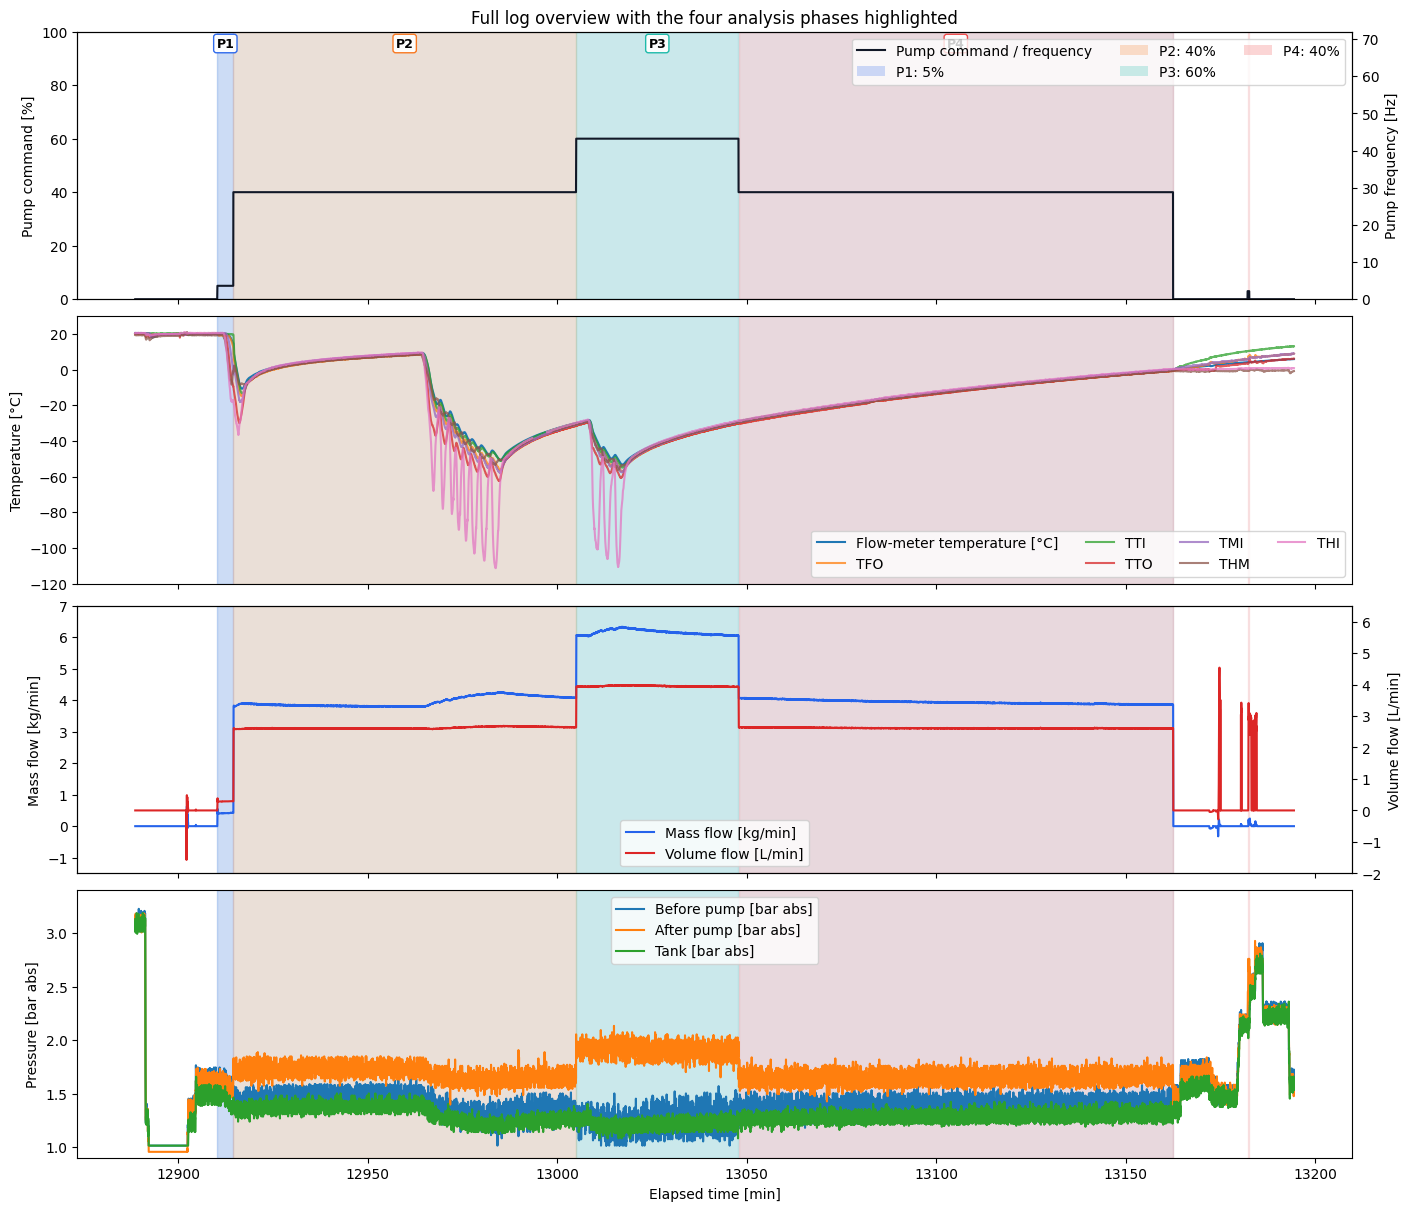

In [5]:
plot_main_overview_with_phases()
plt.show()


## Heat Leaks and Cooldown Power

Three warmup and cooldown segments are extracted directly from the flow-meter temperature signal. Each segment is fit with ORCA's heat-leak and cooldown models.

### Heat Leaks

CONCISE MODEL DETAILS.


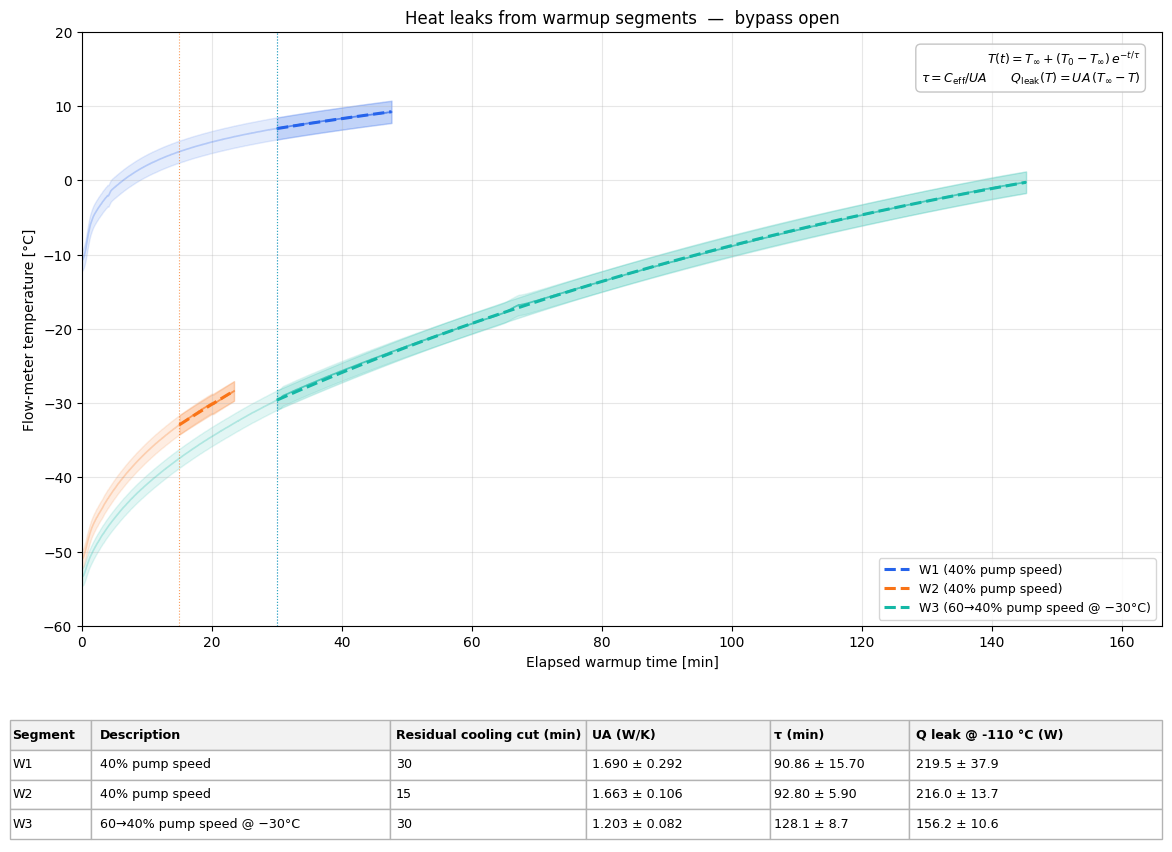

In [6]:
TARGET_COLD_TEMP_C = -110.0

run_fm = run_liquid.sort_values('time_s').reset_index(drop=True).copy()
run_fm['pump_input_power_w'] = pd.to_numeric(run_fm['pump_input_power_w'], errors='coerce').clip(lower=0.0)

WARMUP_DEFS = [
    ('W1', '#2563eb', '40% pump speed',               775009.4, 777868.9, 30.0),
    ('W2', '#f97316', '40% pump speed',                779099.1, 780504.6, 15.0),
    ('W3', '#14b8a6', '60→40% pump speed @ −30°C',    781033.4, 789749.9, 30.0),
]

fig, warmup_results = orca.plot_warmup_segment_fits(
    WARMUP_DEFS, run_fm,
    active_hfe_liquid_kg=ACTIVE_HFE_LIQUID_KG,
    target_cold_temp_c=TARGET_COLD_TEMP_C,
)
display(fig)
plt.close(fig)


### Cooldown Power

CONCISE MODEL DETAILS.


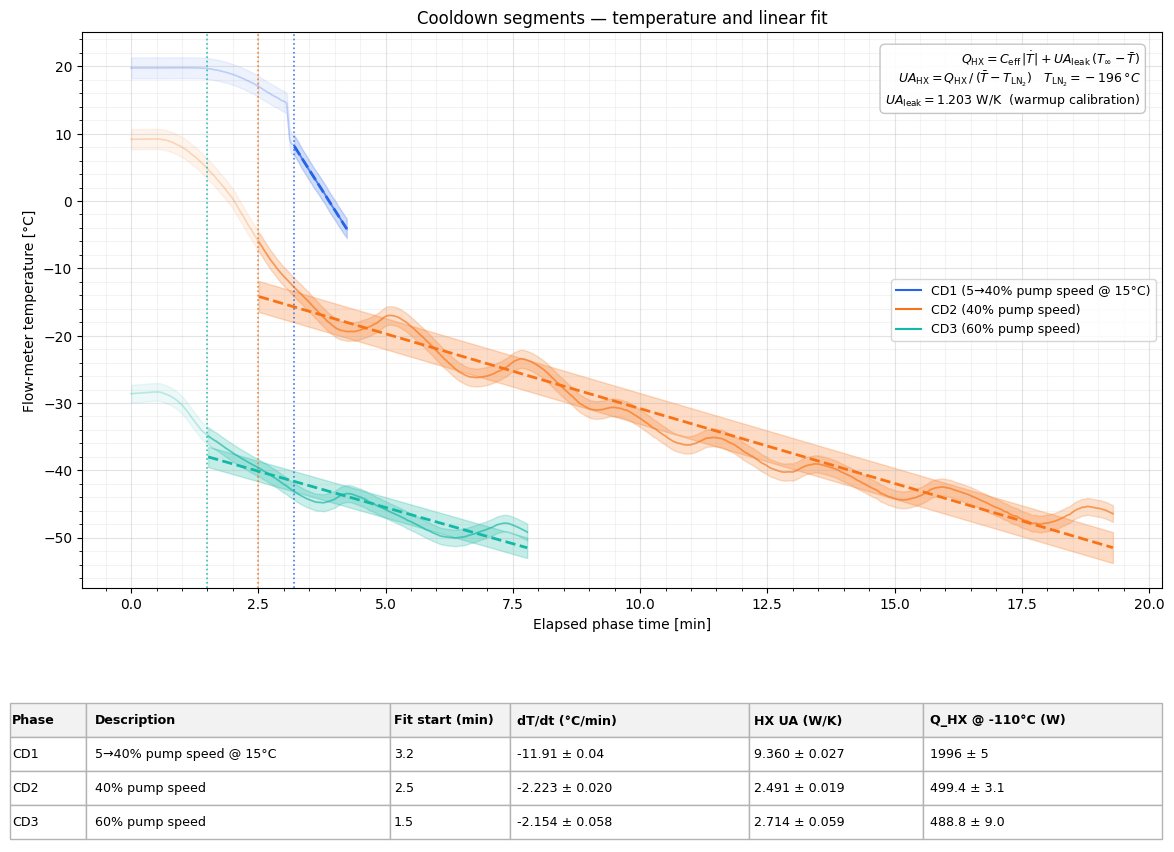

In [7]:
# Cooldown windows: defined by actual LN valve open/close activity
# (label, color, desc, t_start_s, t_end_s, fit_start_min)
COOLDOWN_DEFS = [
    ('CD1', '#2563eb', '5→40% pump speed @ 15°C', 774687.9, 774942.2, 3.2),
    ('CD2', '#f97316', '40% pump speed',                   777839.9, 779000.9, 2.5),
    ('CD3', '#14b8a6', '60% pump speed',                   780473.8, 780942.5, 1.5),
]

cooldown_frames = [
    (label, color, run[run['time_s'].between(t0, t1)].copy().reset_index(drop=True), fit_start_min, desc)
    for label, color, desc, t0, t1, fit_start_min in COOLDOWN_DEFS
]

fig, phase_power_summary = orca.plot_cooldown_power_summary(
    cooldown_frames,
    ua_ambient_w_per_k=warmup_results[2]['fit'].ua_w_per_k,
    active_hfe_liquid_kg=ACTIVE_HFE_LIQUID_KG,
)
display(fig)
plt.close(fig)

#### Pump power contribution

The circulating pump is VFD-controlled. Its electrical input power ranges from ~50 W (CD1, 40% speed) to ~77 W (CD3, 60% speed). 
However, the relevant quantity for the fluid energy balance is the **hydraulic power** actually delivered to the fluid: $P_\mathrm{hyd} = \Delta P \times \dot{V}$.

Measured values across the cooldown segments:

| Segment | $\Delta P$ (bar) | $\dot{V}$ (L/s) | $P_\mathrm{hyd}$ (W) | $P_\mathrm{elec}$ (W) |
|---------|-----------------|-----------------|----------------------|----------------------|
| CD1 | 0.11 | 0.022 | 0.5 | 52 |
| CD2 | 0.31 | 0.044 | 1.4 | 68 |
| CD3 | 0.72 | 0.066 | 4.8 | 77 |

The ~50–77 W electrical input is almost entirely dissipated in the VFD and motor, which sit **outside the fluid loop** and do not heat the HFE. 
Only the hydraulic power enters the fluid, and at 0.5–5 W it is less than **1% of the HX cooling power** (~400–500 W). 
It is therefore negligible in both the heat leak calibration (warmup) and the cooldown energy balance, and is omitted from the model.

## Temperature Evolution and Spatial Stratification

The calibrated thermocouple array and the flow-meter temperature let us separate three different pieces of the thermal story:

1. how deeply each commanded phase cools before rebounding;
2. how strongly the bath stratifies while it is being pulled colder;
3. which sensor locations stay persistently warmest or coldest, rather than only at a single-sample extreme.

The summary table below therefore reports per-phase minima, characteristic stratification using the `95th` percentile TC span, and the dominant cold/warm sensors. The plots use a short rolling-median smoothing window only to suppress sample-to-sample noise; the reported numbers still come from the calibrated measurements.


In [8]:
# Temperature-evolution summary metrics

from scipy.stats import linregress
from IPython.display import Markdown
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

TEMP_SMOOTH_WINDOW_S = 45.0


def _rolling_median(series, elapsed_s, duration_s=TEMP_SMOOTH_WINDOW_S, minimum=7):
    values = pd.to_numeric(series, errors='coerce')
    elapsed = pd.to_numeric(elapsed_s, errors='coerce')
    if len(values) <= minimum:
        return values

    dt = elapsed.diff().dropna()
    dt = dt[dt > 0]
    median_step_s = float(dt.median()) if not dt.empty else max(duration_s / minimum, 1.0)
    window = max(minimum, int(round(duration_s / median_step_s)))
    if window % 2 == 0:
        window += 1

    max_window = len(values) if len(values) % 2 == 1 else len(values) - 1
    max_window = max(max_window, minimum)
    window = min(window, max_window)
    return values.rolling(window, center=True, min_periods=max(5, window // 4)).median().interpolate(limit_direction='both')



def _linear_rate_c_per_min(x_s, y_c):
    x_values = np.asarray(x_s, dtype=float)
    y_values = np.asarray(y_c, dtype=float)
    mask = np.isfinite(x_values) & np.isfinite(y_values)
    if mask.sum() < 3 or np.allclose(x_values[mask], x_values[mask][0]):
        return np.nan

    fit = linregress(x_values[mask], y_values[mask])
    return float(fit.slope * 60.0)



temperature_plot_frames = {}
phase_temperature_rows = []

for phase_key in PHASE_ORDER:
    work = phase_frames[phase_key].copy().reset_index(drop=True)
    for column in list(review.valid_temp_cols) + ['temperature_c_si', 'temp_mean_C', 'temp_span_C', 'tc_min_C', 'tc_max_C']:
        work[f'{column}_smooth'] = _rolling_median(work[column], work['elapsed_phase_s'])

    work['tc_mean_minus_flow_C'] = work['temp_mean_C'] - work['temperature_c_si']
    work['tc_mean_minus_flow_smooth_C'] = work['temp_mean_C_smooth'] - work['temperature_c_si_smooth']

    mean_min_idx = int(work['temp_mean_C'].idxmin())
    coldest_fraction = work[list(review.valid_temp_cols)].idxmin(axis=1).value_counts(normalize=True)
    warmest_fraction = work[list(review.valid_temp_cols)].idxmax(axis=1).value_counts(normalize=True)

    phase_temperature_rows.append(
        {
            'phase': phase_key,
            'phase_title': PHASE_TITLES[phase_key],
            'command_pct': float(work['pump_cmd_pct'].median()),
            'duration_min': float(work['elapsed_phase_s'].iloc[-1] / 60.0),
            'flow_min_C': float(work['temperature_c_si'].min()),
            'tc_mean_min_C': float(work['temp_mean_C'].min()),
            'tc_coldest_min_C': float(work['tc_min_C'].min()),
            'span_p95_C': float(work['temp_span_C'].quantile(0.95)),
            'span_max_C': float(work['temp_span_C'].max()),
            'time_to_tc_mean_min_min': float(work.loc[mean_min_idx, 'elapsed_phase_s'] / 60.0),
            'cooling_rate_tc_mean_C_per_min': _linear_rate_c_per_min(
                work.loc[:mean_min_idx, 'elapsed_phase_s'],
                work.loc[:mean_min_idx, 'temp_mean_C'],
            ),
            'warmup_rate_tc_mean_C_per_min': _linear_rate_c_per_min(
                work.loc[mean_min_idx:, 'elapsed_phase_s'],
                work.loc[mean_min_idx:, 'temp_mean_C'],
            ),
            'dominant_coldest_tc': orca.tc_display_name(coldest_fraction.idxmax()),
            'dominant_warmest_tc': orca.tc_display_name(warmest_fraction.idxmax()),
        }
    )
    temperature_plot_frames[phase_key] = work

phase_temperature_summary = pd.DataFrame(phase_temperature_rows).set_index('phase').loc[list(PHASE_ORDER)]

sensor_temperature_summary = (
    pd.DataFrame(
        {
            'sensor': list(review.valid_temp_cols),
            'median_C': [float(analysis_cd[col].median()) for col in review.valid_temp_cols],
            'mean_C': [float(analysis_cd[col].mean()) for col in review.valid_temp_cols],
            'min_C': [float(analysis_cd[col].min()) for col in review.valid_temp_cols],
            'max_C': [float(analysis_cd[col].max()) for col in review.valid_temp_cols],
        }
    )
    .assign(display=lambda df: df['sensor'].map(orca.tc_display_name))
    .sort_values('median_C')
    .reset_index(drop=True)
)

phase_temperature_display = phase_temperature_summary[
    [
        'command_pct',
        'duration_min',
        'flow_min_C',
        'tc_mean_min_C',
        'tc_coldest_min_C',
        'span_p95_C',
        'time_to_tc_mean_min_min',
        'cooling_rate_tc_mean_C_per_min',
        'dominant_coldest_tc',
        'dominant_warmest_tc',
    ]
].rename(
    columns={
        'command_pct': 'pump_cmd_pct',
        'duration_min': 'phase_duration_min',
        'tc_coldest_min_C': 'coldest_tc_min_C',
        'span_p95_C': 'tc_span_p95_C',
        'time_to_tc_mean_min_min': 'time_to_tc_mean_min_min',
        'cooling_rate_tc_mean_C_per_min': 'tc_mean_cooling_rate_C_per_min',
    }
)

display(phase_temperature_display.round(2))

deepest_phase = phase_temperature_summary['tc_mean_min_C'].idxmin()
fastest_phase = phase_temperature_summary['cooling_rate_tc_mean_C_per_min'].idxmin()
most_stratified_phase = phase_temperature_summary['span_p95_C'].idxmax()
most_uniform_phase = phase_temperature_summary['span_p95_C'].idxmin()

display(
    Markdown(
        f"""
**Quick takeaways**

- `P1` behaves like a weak-mixing check: the flow-meter temperature only falls to `{phase_temperature_summary.loc['P1', 'flow_min_C']:.1f} C`, while the coldest calibrated TC still reaches `{phase_temperature_summary.loc['P1', 'tc_coldest_min_C']:.1f} C`.
- `{deepest_phase}` reaches the deepest bulk state, with TC mean `{phase_temperature_summary.loc[deepest_phase, 'tc_mean_min_C']:.1f} C` after `{phase_temperature_summary.loc[deepest_phase, 'time_to_tc_mean_min_min']:.1f} min`.
- `{fastest_phase}` gives the steepest pre-minimum bulk cooling rate: `{phase_temperature_summary.loc[fastest_phase, 'cooling_rate_tc_mean_C_per_min']:.2f} C/min`.
- `{most_stratified_phase}` is the most stratified phase, with a `95th`-percentile TC span of `{phase_temperature_summary.loc[most_stratified_phase, 'span_p95_C']:.1f} C`; `{most_uniform_phase}` collapses back to `{phase_temperature_summary.loc[most_uniform_phase, 'span_p95_C']:.1f} C`.
"""
    )
)


,pump_cmd_pct,phase_duration_min,flow_min_C,tc_mean_min_C,coldest_tc_min_C,tc_span_p95_C,time_to_tc_mean_min_min,tc_mean_cooling_rate_C_per_min,dominant_coldest_tc,dominant_warmest_tc
phase,,,,,,,,,,
P1,5.0,4.18,14.82,0.74,-18.13,37.48,4.18,-5.29,THI,TTI
P2,40.0,90.44,-51.05,-63.04,-111.39,50.93,69.28,-0.67,TFO,THI
P3,60.0,42.85,-53.37,-64.36,-110.71,54.19,11.36,-3.39,TTO,THI
P4,40.0,114.66,-29.30,-29.58,-30.29,1.75,0.00,NaN,TTO,THI



**Quick takeaways**

- `P1` behaves like a weak-mixing check: the flow-meter temperature only falls to `14.8 C`, while the coldest calibrated TC still reaches `-18.1 C`.
- `P3` reaches the deepest bulk state, with TC mean `-64.4 C` after `11.4 min`.
- `P1` gives the steepest pre-minimum bulk cooling rate: `-5.29 C/min`.
- `P3` is the most stratified phase, with a `95th`-percentile TC span of `54.2 C`; `P4` collapses back to `1.7 C`.


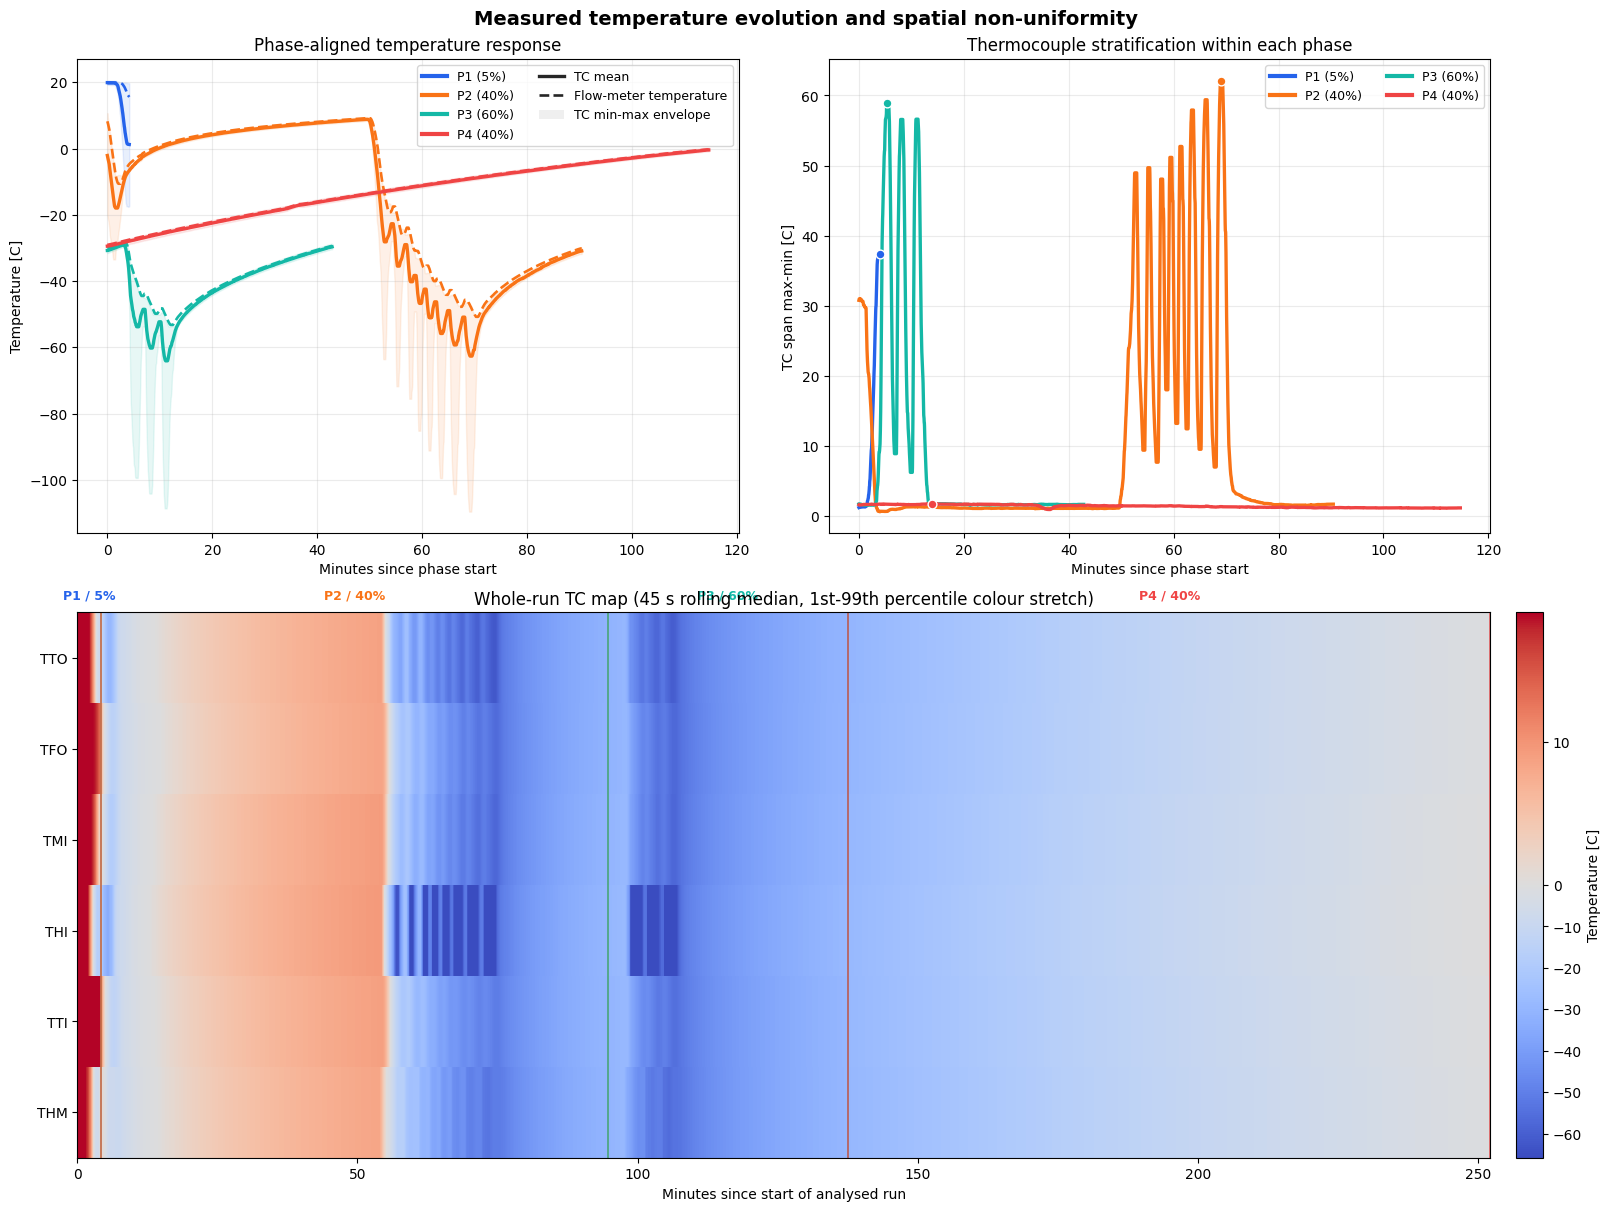

In [9]:
# Temperature-evolution plots

fig = plt.figure(figsize=(16, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15])
ax_traj = fig.add_subplot(gs[0, 0])
ax_span = fig.add_subplot(gs[0, 1])
ax_map = fig.add_subplot(gs[1, :])

for phase_key in PHASE_ORDER:
    work = temperature_plot_frames[phase_key]
    elapsed_phase_min = work['elapsed_phase_s'] / 60.0
    color = PHASE_COLORS[phase_key]

    ax_traj.fill_between(
        elapsed_phase_min,
        work['tc_min_C_smooth'],
        work['tc_max_C_smooth'],
        color=color,
        alpha=0.10,
    )
    ax_traj.plot(elapsed_phase_min, work['temp_mean_C_smooth'], color=color, lw=2.4)
    ax_traj.plot(elapsed_phase_min, work['temperature_c_si_smooth'], color=color, lw=1.9, ls='--')

    ax_span.plot(elapsed_phase_min, work['temp_span_C_smooth'], color=color, lw=2.4, label=phase_key)
    peak_idx = int(work['temp_span_C_smooth'].idxmax())
    ax_span.scatter(
        work.loc[peak_idx, 'elapsed_phase_s'] / 60.0,
        work.loc[peak_idx, 'temp_span_C_smooth'],
        s=40,
        color=color,
        edgecolor='white',
        zorder=5,
    )

phase_handles = [
    Line2D([0], [0], color=PHASE_COLORS[key], lw=3, label=f"{key} ({phase_temperature_summary.loc[key, 'command_pct']:.0f}%)")
    for key in PHASE_ORDER
]
style_handles = [
    Line2D([0], [0], color='0.15', lw=2.4, label='TC mean'),
    Line2D([0], [0], color='0.15', lw=1.9, ls='--', label='Flow-meter temperature'),
    Patch(facecolor='0.5', alpha=0.12, label='TC min-max envelope'),
]

ax_traj.legend(handles=phase_handles + style_handles, ncol=2, fontsize=9, loc='best')
ax_traj.set_title('Phase-aligned temperature response')
ax_traj.set_xlabel('Minutes since phase start')
ax_traj.set_ylabel('Temperature [C]')
ax_traj.grid(True, alpha=0.25)

ax_span.legend(handles=phase_handles, ncol=2, fontsize=9, loc='best')
ax_span.set_title('Thermocouple stratification within each phase')
ax_span.set_xlabel('Minutes since phase start')
ax_span.set_ylabel('TC span max-min [C]')
ax_span.grid(True, alpha=0.25)

sensor_order = sensor_temperature_summary['sensor'].tolist()
heatmap = analysis_cd[sensor_order].copy()
for column in sensor_order:
    heatmap[column] = _rolling_median(heatmap[column], analysis_cd['elapsed_run_s'])

heatmap_values = heatmap.to_numpy(dtype=float)
vmin, vmax = np.nanpercentile(heatmap_values, [1, 99])
if vmin < 0 < vmax:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
else:
    norm = None

image = ax_map.imshow(
    heatmap_values.T,
    aspect='auto',
    interpolation='nearest',
    cmap='coolwarm',
    norm=norm,
    extent=[
        float(analysis_cd['elapsed_run_s'].min() / 60.0),
        float(analysis_cd['elapsed_run_s'].max() / 60.0),
        len(sensor_order) - 0.5,
        -0.5,
    ],
)

ax_map.set_yticks(range(len(sensor_order)), labels=sensor_temperature_summary['display'])
ax_map.set_xlabel('Minutes since start of analysed run')
ax_map.set_title('Whole-run TC map (45 s rolling median, 1st-99th percentile colour stretch)')

for phase_key in PHASE_ORDER:
    start_min = float(temperature_plot_frames[phase_key]['elapsed_run_s'].iloc[0] / 60.0)
    end_min = float(temperature_plot_frames[phase_key]['elapsed_run_s'].iloc[-1] / 60.0)
    midpoint = 0.5 * (start_min + end_min)
    ax_map.axvline(start_min, color=PHASE_COLORS[phase_key], lw=1.2, alpha=0.8)
    ax_map.axvline(end_min, color=PHASE_COLORS[phase_key], lw=1.2, alpha=0.8)
    ax_map.text(
        midpoint,
        1.02,
        f"{phase_key} / {phase_temperature_summary.loc[phase_key, 'command_pct']:.0f}%",
        transform=ax_map.get_xaxis_transform(),
        ha='center',
        va='bottom',
        fontsize=9,
        color=PHASE_COLORS[phase_key],
        fontweight='bold',
    )

colorbar = fig.colorbar(image, ax=ax_map, pad=0.01)
colorbar.set_label('Temperature [C]')
fig.suptitle('Measured temperature evolution and spatial non-uniformity', fontsize=14, fontweight='bold')
display(fig)
plt.close(fig)


## Loop Warming and Mixing: 40% vs 60%

`P1` is excluded here because it is too short to support a meaningful mixing comparison. For the actual pump-speed comparison I use only `P2` (`40%`) and `P3` (`60%`), and I restrict the analysis to their shared bulk-temperature range so the two speeds are compared at the same thermal state rather than at different timestamps.

Three complementary views are plotted below:

1. `TTI - TTO`, as a proxy for how much HFE warms between those two probe locations;
2. `THI` versus `THM`, where a better-mixed bath sits closer to the `THI = THM` diagonal;
3. a bounded mixing-efficiency proxy based on the full connected-TC span.

The mixing proxy is defined as

`eta_mix_proxy = 1 - DeltaT_TC_span / max(|T_TC_mean|, 5 C)`

with `DeltaT_TC_span = max(TC) - min(TC)` over the connected thermocouples. It is not a first-principles efficiency in the CFD sense; it is a compact spatial-uniformity index for this run, where larger values mean the bath is more nearly isothermal.


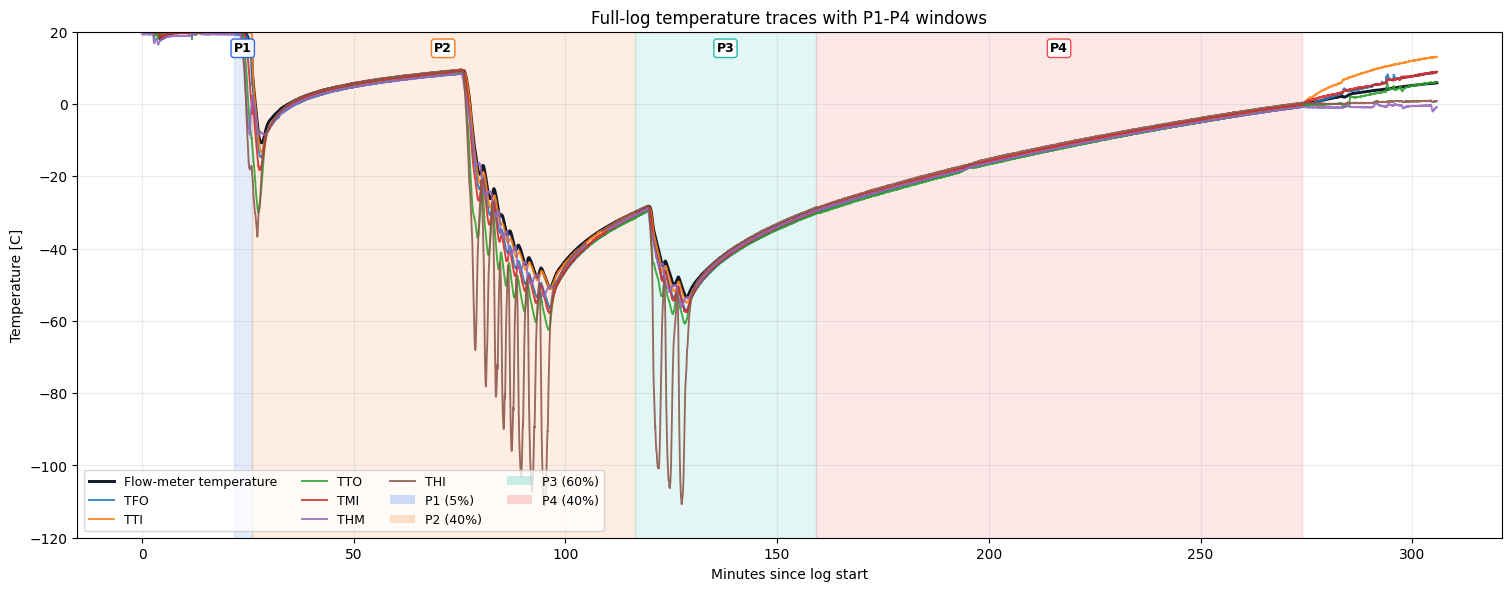

In [10]:
# Full-log temperature overview for the speed-comparison section

speed_full_log = review.data.copy().sort_values('time_s').reset_index(drop=True)
log_start_s = float(speed_full_log['time_s'].iloc[0])
speed_full_log['elapsed_log_min'] = (speed_full_log['time_s'] - log_start_s) / 60.0

fig, ax = plt.subplots(figsize=(15, 5.8), constrained_layout=True)
phase_handles = []

for phase_key in PHASE_ORDER:
    start_min = float(phase_summary.loc[phase_key, 'start_min_in_log'] - log_start_s / 60.0)
    end_min = float(phase_summary.loc[phase_key, 'end_min_in_log'] - log_start_s / 60.0)
    midpoint = 0.5 * (start_min + end_min)
    ax.axvspan(start_min, end_min, color=PHASE_COLORS[phase_key], alpha=0.12)
    ax.text(
        midpoint,
        0.98,
        phase_key,
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec=PHASE_COLORS[phase_key], alpha=0.95),
    )
    phase_handles.append(
        Patch(facecolor=PHASE_COLORS[phase_key], edgecolor='none', alpha=0.22, label=f"{phase_key} ({phase_summary.loc[phase_key, 'command_pct']:.0f}%)")
    )

ax.plot(
    speed_full_log['elapsed_log_min'],
    speed_full_log['temperature_c_si'],
    color='#111827',
    lw=2.1,
    label='Flow-meter temperature',
)
for column in review.valid_temp_cols:
    ax.plot(
        speed_full_log['elapsed_log_min'],
        speed_full_log[column],
        lw=1.35,
        alpha=0.88,
        label=orca.tc_display_name(column),
    )

line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(
    line_handles + phase_handles,
    line_labels + [handle.get_label() for handle in phase_handles],
    loc='lower left',
    ncols=4,
    fontsize=9,
)
ax.set_title('Full-log temperature traces with P1-P4 windows')
ax.set_xlabel('Minutes since log start')
ax.set_ylabel('Temperature [C]')
ax.set_ylim(-120.0, 20.0)
ax.grid(True, alpha=0.25)
display(fig)
plt.close(fig)


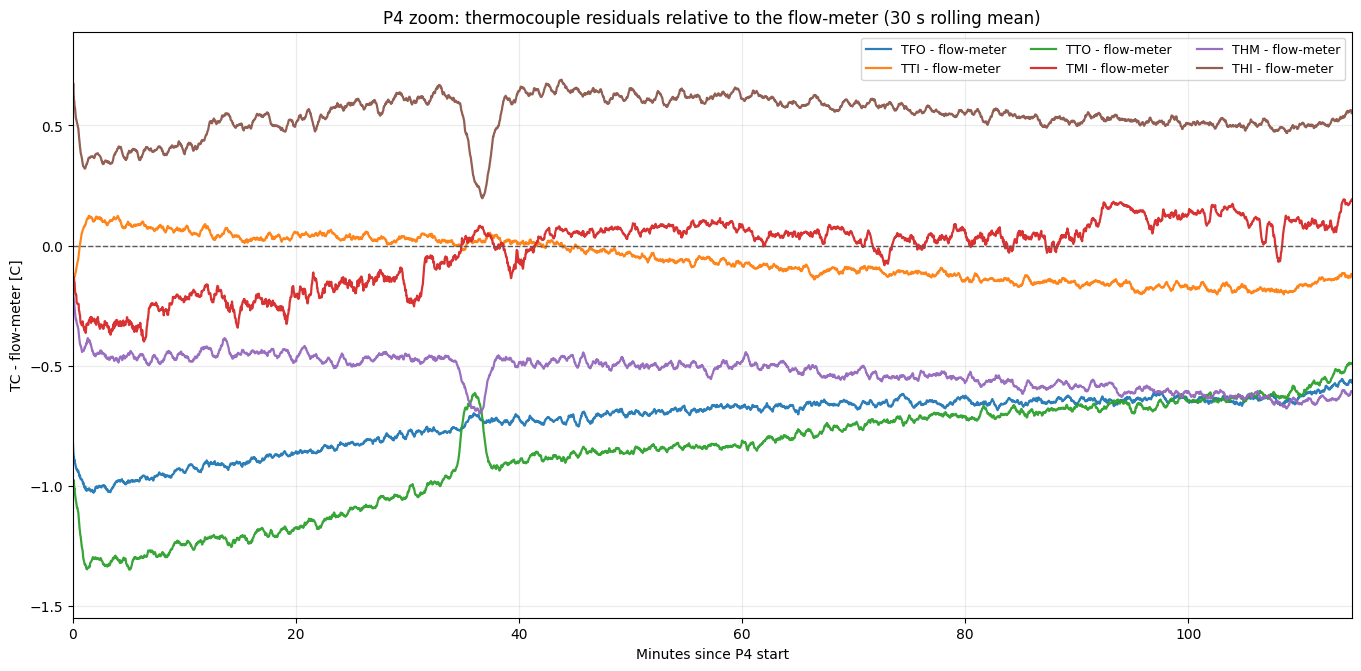

In [11]:
# P4 zoomed temperature plot (30 s rolling mean)

p4_frame = phase_frames['P4'].copy().sort_values('time_s').reset_index(drop=True)
p4_frame['elapsed_p4_min'] = p4_frame['elapsed_phase_s'] / 60.0

p4_smooth_cols = list(review.valid_temp_cols) + ['temperature_c_si']
p4_time_index = pd.to_timedelta(p4_frame['time_s'], unit='s')
p4_smoothed = (
    p4_frame[p4_smooth_cols]
    .set_axis(p4_time_index)
    .rolling('30s', min_periods=1)
    .mean()
    .to_numpy()
)
for i, col in enumerate(p4_smooth_cols):
    p4_frame[f'{col}_smooth30s'] = p4_smoothed[:, i]

for column in review.valid_temp_cols:
    p4_frame[f'{column}_minus_flow_C'] = (
        p4_frame[f'{column}_smooth30s'] - p4_frame['temperature_c_si_smooth30s']
    )

p4_residual_cols = [f'{column}_minus_flow_C' for column in review.valid_temp_cols]
p4_residual_min_C = float(np.nanmin(p4_frame[p4_residual_cols].to_numpy(dtype=float)))
p4_residual_max_C = float(np.nanmax(p4_frame[p4_residual_cols].to_numpy(dtype=float)))
p4_residual_span_C = max(p4_residual_max_C - p4_residual_min_C, 0.5)
p4_residual_pad_C = max(0.2, 0.08 * p4_residual_span_C)
p4_residual_ylim = (
    p4_residual_min_C - p4_residual_pad_C,
    p4_residual_max_C + p4_residual_pad_C,
)

fig, ax = plt.subplots(figsize=(13.5, 6.6), constrained_layout=True)
for column in review.valid_temp_cols:
    display_name = orca.tc_display_name(column)
    ax.plot(
        p4_frame['elapsed_p4_min'],
        p4_frame[f'{column}_minus_flow_C'],
        lw=1.6,
        alpha=0.95,
        label=f'{display_name} - flow-meter',
    )

ax.axhline(0.0, color='0.35', ls='--', lw=1.0)
ax.set_title('P4 zoom: thermocouple residuals relative to the flow-meter (30 s rolling mean)')
ax.set_xlabel('Minutes since P4 start')
ax.set_ylabel('TC - flow-meter [C]')
ax.set_xlim(float(p4_frame['elapsed_p4_min'].min()), float(p4_frame['elapsed_p4_min'].max()))
ax.set_ylim(*p4_residual_ylim)
ax.grid(True, alpha=0.25)
ax.legend(loc='best', ncols=3, fontsize=9)
display(fig)
plt.close(fig)


In [12]:
# 40% vs 60% speed-comparison metrics

speed_compare_keys = ('P2', 'P3')
speed_compare_frames = {
    key: temperature_plot_frames[key].copy().reset_index(drop=True)
    for key in speed_compare_keys
}

for key, work in speed_compare_frames.items():
    work['phase'] = key
    work['d_tti_tto_C'] = work['TTI_C'] - work['TTO_C']
    work['d_thi_thm_C'] = work['THI_C'] - work['THM_C']
    work['mix_eff_proxy'] = 1.0 - (work['temp_span_C'] / work['temp_mean_C'].abs().clip(lower=5.0)).clip(0.0, 1.0)
    for column in ['d_tti_tto_C', 'THI_C', 'THM_C', 'mix_eff_proxy']:
        work[f'{column}_smooth'] = _rolling_median(work[column], work['elapsed_phase_s'])
    speed_compare_frames[key] = work

common_low_C = max(speed_compare_frames['P2']['temp_mean_C'].min(), speed_compare_frames['P3']['temp_mean_C'].min())
common_high_C = min(speed_compare_frames['P2']['temp_mean_C'].max(), speed_compare_frames['P3']['temp_mean_C'].max())

for key in speed_compare_keys:
    speed_compare_frames[key] = speed_compare_frames[key][
        speed_compare_frames[key]['temp_mean_C'].between(common_low_C, common_high_C)
    ].copy()

speed_compare = pd.concat(speed_compare_frames.values(), ignore_index=True)
bin_edges_C = np.arange(np.floor(common_low_C / 5.0) * 5.0, np.ceil(common_high_C / 5.0) * 5.0 + 5.0, 5.0)
speed_compare['temp_bin'] = pd.cut(speed_compare['temp_mean_C'], bins=bin_edges_C, include_lowest=True)

speed_binned_compare = (
    speed_compare.groupby(['phase', 'temp_bin'], observed=False)
    .agg(
        temp_mean_mid_C=('temp_mean_C', 'median'),
        n_samples=('temp_mean_C', 'size'),
        d_tti_tto_med_C=('d_tti_tto_C', 'median'),
        d_thi_thm_med_C=('d_thi_thm_C', 'median'),
        tc_span_med_C=('temp_span_C', 'median'),
        mix_eff_med=('mix_eff_proxy', 'median'),
        THI_med_C=('THI_C', 'median'),
        THM_med_C=('THM_C', 'median'),
    )
    .reset_index()
)
speed_binned_compare = speed_binned_compare[speed_binned_compare['n_samples'] >= 10].copy()

speed_overlap_summary = (
    speed_compare.groupby('phase')
    .agg(
        pump_cmd_pct=('pump_cmd_pct', 'median'),
        bulk_temp_med_C=('temp_mean_C', 'median'),
        mass_flow_med_kgmin=('mass_flow_kgmin_si', 'median'),
        tti_minus_tto_med_C=('d_tti_tto_C', 'median'),
        thi_minus_thm_med_C=('d_thi_thm_C', 'median'),
        tc_span_med_C=('temp_span_C', 'median'),
        mix_eff_med=('mix_eff_proxy', 'median'),
    )
    .round(3)
)

speed_cold_summary = (
    speed_compare[speed_compare['temp_mean_C'] <= -50.0]
    .groupby('phase')
    .agg(
        tti_minus_tto_med_C=('d_tti_tto_C', 'median'),
        thi_minus_thm_med_C=('d_thi_thm_C', 'median'),
        tc_span_med_C=('temp_span_C', 'median'),
        mix_eff_med=('mix_eff_proxy', 'median'),
    )
    .round(3)
)

display(Markdown(f"**Shared bulk-temperature range used for the speed comparison:** {common_low_C:.1f} C to {common_high_C:.1f} C"))
display(speed_overlap_summary)
display(Markdown('**Colder subset only (`T_TC_mean <= -50 C`):**'))
display(speed_cold_summary)

display(
    Markdown(
        f"""
**What changes with pump speed?**

- Over the full shared range, `60%` circulation carries higher flow (`{speed_overlap_summary.loc['P3', 'mass_flow_med_kgmin']:.2f}` vs `{speed_overlap_summary.loc['P2', 'mass_flow_med_kgmin']:.2f} kg/min`) and leaves a slightly smaller median TC span (`{speed_overlap_summary.loc['P3', 'tc_span_med_C']:.2f}` vs `{speed_overlap_summary.loc['P2', 'tc_span_med_C']:.2f} C`).
- The difference becomes much clearer once the bath is cold: below `-50 C`, the median connected-TC span falls from `{speed_cold_summary.loc['P2', 'tc_span_med_C']:.2f} C` at `40%` to `{speed_cold_summary.loc['P3', 'tc_span_med_C']:.2f} C` at `60%`.
- In the same cold subset, `THI - THM` shrinks in magnitude from `{speed_cold_summary.loc['P2', 'thi_minus_thm_med_C']:.2f} C` to `{speed_cold_summary.loc['P3', 'thi_minus_thm_med_C']:.2f} C`, so the top-mid thermal gradient is substantially reduced at `60%`.
- `TTI - TTO` also drops from `{speed_cold_summary.loc['P2', 'tti_minus_tto_med_C']:.2f} C` to `{speed_cold_summary.loc['P3', 'tti_minus_tto_med_C']:.2f} C`, which is consistent with higher recirculation reducing the per-pass temperature rise while improving bulk uniformity.
"""
    )
)


**Shared bulk-temperature range used for the speed comparison:** -63.0 C to -29.0 C

,pump_cmd_pct,bulk_temp_med_C,mass_flow_med_kgmin,tti_minus_tto_med_C,thi_minus_thm_med_C,tc_span_med_C,mix_eff_med
phase,,,,,,,
P2,40.0,-41.916,4.143,2.936,-2.99,2.943,0.938
P3,60.0,-38.712,6.144,0.904,0.81,1.683,0.951


**Colder subset only (`T_TC_mean <= -50 C`):**

,tti_minus_tto_med_C,thi_minus_thm_med_C,tc_span_med_C,mix_eff_med
phase,,,,
P2,10.502,-39.45,41.33,0.269
P3,5.751,-20.24,20.63,0.626



**What changes with pump speed?**

- Over the full shared range, `60%` circulation carries higher flow (`6.14` vs `4.14 kg/min`) and leaves a slightly smaller median TC span (`1.68` vs `2.94 C`).
- The difference becomes much clearer once the bath is cold: below `-50 C`, the median connected-TC span falls from `41.33 C` at `40%` to `20.63 C` at `60%`.
- In the same cold subset, `THI - THM` shrinks in magnitude from `-39.45 C` to `-20.24 C`, so the top-mid thermal gradient is substantially reduced at `60%`.
- `TTI - TTO` also drops from `10.50 C` to `5.75 C`, which is consistent with higher recirculation reducing the per-pass temperature rise while improving bulk uniformity.


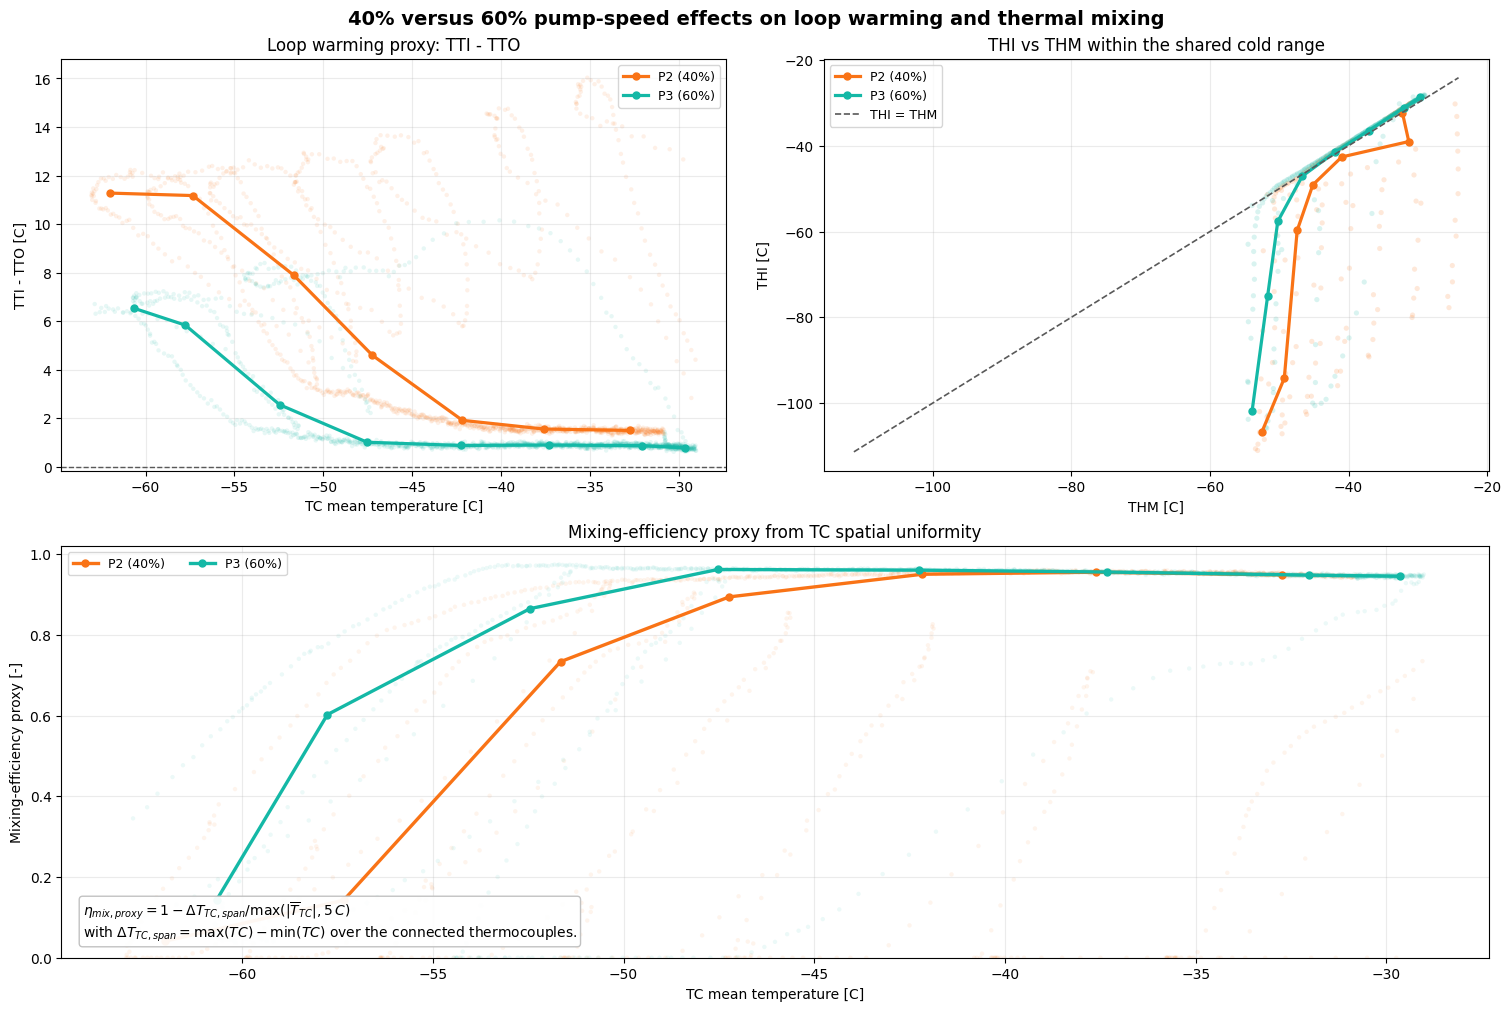

In [13]:
# 40% vs 60% speed-comparison plots

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0])
ax_loop = fig.add_subplot(gs[0, 0])
ax_tank = fig.add_subplot(gs[0, 1])
ax_mix = fig.add_subplot(gs[1, :])

for phase_key in speed_compare_keys:
    work = speed_compare_frames[phase_key]
    binned = speed_binned_compare[speed_binned_compare['phase'] == phase_key]
    color = PHASE_COLORS[phase_key]
    label = f"{phase_key} ({work['pump_cmd_pct'].median():.0f}%)"

    ax_loop.scatter(
        work['temp_mean_C'],
        work['d_tti_tto_C'],
        s=10,
        alpha=0.10,
        color=color,
        edgecolors='none',
    )
    ax_loop.plot(
        binned['temp_mean_mid_C'],
        binned['d_tti_tto_med_C'],
        marker='o',
        ms=5,
        lw=2.3,
        color=color,
        label=label,
    )

    sample = work.iloc[::5].copy()
    ax_tank.scatter(
        sample['THM_C'],
        sample['THI_C'],
        s=14,
        alpha=0.16,
        color=color,
        edgecolors='none',
    )
    ax_tank.plot(
        binned['THM_med_C'],
        binned['THI_med_C'],
        marker='o',
        ms=5,
        lw=2.3,
        color=color,
        label=label,
    )

    ax_mix.scatter(
        work['temp_mean_C'],
        work['mix_eff_proxy'],
        s=10,
        alpha=0.08,
        color=color,
        edgecolors='none',
    )
    ax_mix.plot(
        binned['temp_mean_mid_C'],
        binned['mix_eff_med'],
        marker='o',
        ms=5,
        lw=2.4,
        color=color,
        label=label,
    )

ax_loop.axhline(0.0, color='0.35', ls='--', lw=1.0)
ax_loop.set_title('Loop warming proxy: TTI - TTO')
ax_loop.set_xlabel('TC mean temperature [C]')
ax_loop.set_ylabel('TTI - TTO [C]')
ax_loop.grid(True, alpha=0.25)
ax_loop.legend(loc='best', fontsize=9)

all_tank_points = speed_compare[['THM_C', 'THI_C']].copy()
min_temp_C = float(np.nanmin(all_tank_points.min(axis=1)))
max_temp_C = float(np.nanmax(all_tank_points.max(axis=1)))
ax_tank.plot([min_temp_C, max_temp_C], [min_temp_C, max_temp_C], color='0.35', ls='--', lw=1.2, label='THI = THM')
ax_tank.set_title('THI vs THM within the shared cold range')
ax_tank.set_xlabel('THM [C]')
ax_tank.set_ylabel('THI [C]')
ax_tank.grid(True, alpha=0.25)
ax_tank.legend(loc='best', fontsize=9)

ax_mix.set_ylim(0.0, 1.02)
ax_mix.set_title('Mixing-efficiency proxy from TC spatial uniformity')
ax_mix.set_xlabel('TC mean temperature [C]')
ax_mix.set_ylabel('Mixing-efficiency proxy [-]')
ax_mix.grid(True, alpha=0.25)
ax_mix.legend(loc='best', ncols=2, fontsize=9)

mix_formula = (
    r'$\eta_{mix,proxy}=1-\Delta T_{TC,span}/\max(|\overline{T}_{TC}|,5\,C)$'
    + chr(10)
    + r'with $\Delta T_{TC,span}=\max(TC)-\min(TC)$ over the connected thermocouples.'
)
ax_mix.text(
    0.015,
    0.035,
    mix_formula,
    transform=ax_mix.transAxes,
    fontsize=10,
    va='bottom',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.75', alpha=0.95),
)

fig.suptitle('40% versus 60% pump-speed effects on loop warming and thermal mixing', fontsize=14, fontweight='bold')
display(fig)
plt.close(fig)
